# CICDarknet2020 - Traffic Categories Classification (8 classes)

## Loading the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
darknet_file = pd.read_csv('/content/drive/MyDrive/Darknet.csv')

In [3]:
darknet_file.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [4]:
new_cols = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
       'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg',
       'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
       'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg',
       'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets',
       'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Bwd Init Win Bytes',
       'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Active Mean', 'Active Std',
       'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max',
       'Idle Min', 'Label-1', 'Label-2']

In [5]:
darknet_file.columns = new_cols

In [6]:
darknet_file['Label-2'] = darknet_file['Label-2'].replace('AUDIO-STREAMING', 'Audio-Streaming')
darknet_file['Label-2'] = darknet_file['Label-2'].replace('Video-streaming', 'Video-Streaming')
darknet_file['Label-2'] = darknet_file['Label-2'].replace('File-transfer', 'File-Transfer')

In [7]:
darknet_file['Label-2'].value_counts()

,count
Label-2,
P2P,48520
Browsing,46457
Audio-Streaming,21350
Chat,11629
File-Transfer,11182
Video-Streaming,9767
Email,6145
VOIP,3566


## Data Visualization

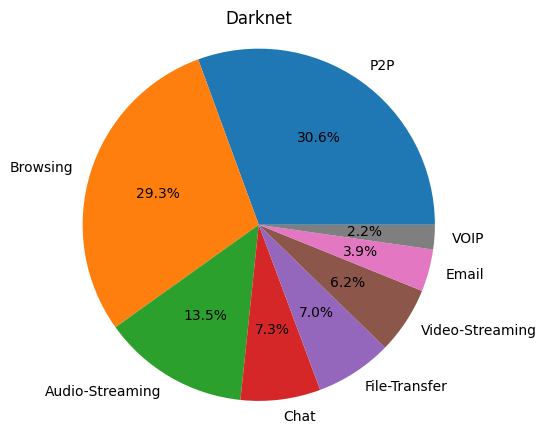

In [8]:
values = darknet_file['Label-2'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(values, labels = ['P2P', 'Browsing', 'Audio-Streaming', 'Chat', 'File-Transfer', 'Video-Streaming', 'Email', 'VOIP'], autopct='%3.1f%%')
plt.axis('equal')
plt.title('Darknet')
plt.show()

## Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

darknet_file['Label-2'] = le.fit_transform(darknet_file['Label-2'])

In [10]:
darknet_file['Label-1'] = le.fit_transform(darknet_file['Label-1'])

In [11]:
darknet_file

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label-1,Label-2
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158611,10.8.8.246-224.0.0.252-55219-5355-17,10.8.8.246,55219,224.0.0.252,5355,17,22/05/2015 01:55:03 PM,411806,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158612,10.8.8.246-224.0.0.252-64207-5355-17,10.8.8.246,64207,224.0.0.252,5355,17,22/05/2015 02:09:05 PM,411574,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158613,10.8.8.246-224.0.0.252-61115-5355-17,10.8.8.246,61115,224.0.0.252,5355,17,22/05/2015 02:19:31 PM,422299,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158614,10.8.8.246-224.0.0.252-64790-5355-17,10.8.8.246,64790,224.0.0.252,5355,17,22/05/2015 02:29:55 PM,411855,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6


## Data Preprocessing

In [12]:
new_data = darknet_file

In [13]:
new_data.drop(columns = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'], inplace=True)

In [14]:
new_data.columns

Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN

In [15]:
import numpy as np

In [16]:
new_data

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label-1,Label-2
0,57158,443,6,229,1,1,0,0,0,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
1,57159,443,6,407,1,1,0,0,0,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
2,57160,443,6,431,1,1,0,0,0,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
3,49134,443,6,359,1,1,0,0,0,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
4,34697,19305,6,10778451,591,400,64530,6659,131,0,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158611,55219,5355,17,411806,2,0,44,0,22,22,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158612,64207,5355,17,411574,2,0,44,0,22,22,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158613,61115,5355,17,422299,2,0,44,0,22,22,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6
158614,64790,5355,17,411855,2,0,44,0,22,22,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,6


In [17]:
print(new_data.isna().sum())

Src Port            0
Dst Port            0
Protocol            0
Flow Duration       0
Total Fwd Packet    0
                   ..
Idle Std            0
Idle Max            0
Idle Min            0
Label-1             0
Label-2             0
Length: 81, dtype: int64


In [18]:
list(new_data.columns)

['Src Port',
 'Dst Port',
 'Protocol',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Co

In [19]:
new_data.replace(np.inf, np.nan, inplace=True)
new_data.dropna(inplace=True)

In [20]:
new_data['Label-2'].value_counts()

,count
Label-2,
5,48520
1,46457
0,21336
2,11623
4,11173
7,9748
3,6143
6,3566


In [21]:
data_scaled_frame = new_data

## Feature Selection Algorithm

In [22]:
incomplete_rows = new_data[new_data.isnull().any(axis=1)]

correlation_matrix_ids = data_scaled_frame.corr()

sample_dataframe = data_scaled_frame.copy(deep=True)

In [23]:
l = correlation_matrix_ids["Label-2"].sort_values(ascending=False)
pearson_values = []
i=0
for name, score in l.items():
    if (name!='Label-2'):
      if (i>65):
        pearson_values.append(0)
      else:
        pearson_values.append(score)
    i+=1


In [24]:
from scipy.stats import spearmanr, kendalltau

spearman_values = data_scaled_frame.corr(method='spearman')["Label-2"].sort_values(ascending=False)
kendall_values = data_scaled_frame.corr(method='kendall')["Label-2"].sort_values(ascending=False)

In [25]:
s_values = []
k_values = []
i = 0
for name,score in spearman_values.items():
    if (name!='Label-2'):
      if (i>65):
        s_values.append(0)
      else:
        s_values.append(score)
    i+=1

i = 0
for name,score in kendall_values.items():
    if (name!='Label-2'):
      if (i>65):
        k_values.append(0)
      else:
        k_values.append(score)
    i+=1


col_headings = ['Pearson', 'Spearman', 'Kendall']
combined_lists = [pearson_values, s_values, k_values]


In [26]:
import numpy as np
from scipy.stats import entropy
from scipy.signal import gauss_spline, hilbert

In [27]:
cols = data_scaled_frame.columns
max_amplitude = []
mean_amplitude = []
h_max_amp = []
h_mean_amp = []
h_ph_max = []



for i in cols:
  if (i=='Label-2'):
    continue

  vals = data_scaled_frame[i].values
  fourier = np.fft.fft(vals)
  amps = np.abs(fourier)
  phase = np.angle(fourier)

  hil_space = hilbert(vals)
  amps_h = np.abs(hil_space)
  phase_h = np.angle(hil_space)

  h_max_amp.append(np.max(amps_h))
  h_mean_amp.append(np.mean(amps_h))
  h_ph_max.append(np.max(phase_h))

  max_amplitude.append(np.max(amps))
  mean_amplitude.append(np.mean(amps))




In [28]:
combined_lists.extend([gauss_spline(max_amplitude, 3), gauss_spline(mean_amplitude, 3), gauss_spline(h_max_amp, 3), gauss_spline(h_mean_amp, 3), gauss_spline(h_ph_max, 3)])

In [29]:
arr = np.array(combined_lists)

In [30]:
inter = np.dot(arr.T, arr)

In [31]:
inter

array([[4.65755131e-01, 3.59710504e-01, 2.94299577e-01, ...,
        2.91209366e-04, 2.91209366e-04, 2.91209366e-04],
       [3.59710504e-01, 2.78546825e-01, 2.28776219e-01, ...,
        2.91209366e-04, 2.91209366e-04, 2.91209366e-04],
       [2.94299577e-01, 2.28776219e-01, 1.89090162e-01, ...,
        2.91209366e-04, 2.91209366e-04, 2.91209366e-04],
       ...,
       [2.91209366e-04, 2.91209366e-04, 2.91209366e-04, ...,
        2.91209366e-04, 2.91209366e-04, 2.91209366e-04],
       [2.91209366e-04, 2.91209366e-04, 2.91209366e-04, ...,
        2.91209366e-04, 2.91209366e-04, 2.91209366e-04],
       [2.91209366e-04, 2.91209366e-04, 2.91209366e-04, ...,
        2.91209366e-04, 2.91209366e-04, 9.22558960e-03]])

In [32]:
eigen_values, eigen_vectors = np.linalg.eig(inter)

In [33]:
eigen_values

array([ 2.93806432e+01+0.00000000e+00j,  4.42596617e+00+0.00000000e+00j,
        8.70884909e-01+0.00000000e+00j,  9.35319197e-02+0.00000000e+00j,
        9.09945902e-03+0.00000000e+00j,  1.68781435e-03+0.00000000e+00j,
        7.98919712e-10+0.00000000e+00j,  1.01180432e-15+0.00000000e+00j,
        6.86918812e-16+0.00000000e+00j, -4.18768166e-16+3.80684931e-16j,
       -4.18768166e-16-3.80684931e-16j, -3.79790370e-16+0.00000000e+00j,
        3.65242476e-16+0.00000000e+00j,  1.71540954e-16+2.55505263e-16j,
        1.71540954e-16-2.55505263e-16j,  2.44608462e-16+1.58197102e-16j,
        2.44608462e-16-1.58197102e-16j, -1.72398384e-16+1.48722153e-17j,
       -1.72398384e-16-1.48722153e-17j,  1.44658461e-16+0.00000000e+00j,
        1.15935343e-16+0.00000000e+00j,  7.84203280e-17+0.00000000e+00j,
       -7.80217892e-17+1.85841613e-18j, -7.80217892e-17-1.85841613e-18j,
        6.10485195e-17+0.00000000e+00j,  4.29275551e-17+4.82924289e-18j,
        4.29275551e-17-4.82924289e-18j, -3.36281028

In [34]:
eigen_vectors = np.abs(eigen_vectors).tolist()

In [35]:
eigen_vectors_arr = np.array(eigen_vectors)

In [36]:
eigen_vectors_arr = np.mean(eigen_vectors_arr, axis=0)

In [37]:
eigen_vectors = eigen_vectors_arr.tolist()

In [38]:
eigen_vectors

[0.05461404274303637,
 0.08903773703489234,
 0.04351691617877671,
 0.08693717711048694,
 0.08898849129337583,
 0.07894236254260381,
 0.03928132709810851,
 0.07421137495107748,
 0.052583239298646764,
 0.07800247084762041,
 0.07800247084762041,
 0.05431483965918086,
 0.06666957105442525,
 0.07989475853739833,
 0.07989475853739833,
 0.06837199237581958,
 0.06837199237581958,
 0.08242812735869168,
 0.08242812735869168,
 0.07895118138775745,
 0.08440348629785858,
 0.07478561372400754,
 0.08151714722689749,
 0.08151714722689749,
 0.07863362500065672,
 0.08500409179030566,
 0.08500409179030566,
 0.08797891331044497,
 0.08797891331044497,
 0.07593374601190064,
 0.07400309056319003,
 0.08851106654247218,
 0.08851106654247218,
 0.09051260875193239,
 0.09051260875193239,
 0.07335401601173218,
 0.08106388810007471,
 0.08106388810007471,
 0.08425412886687107,
 0.08425412886687107,
 0.08959144811274297,
 0.08959144811274297,
 0.0905558700193546,
 0.0905558700193546,
 0.0770518561479526,
 0.080032294

In [39]:
np.mean(eigen_vectors)

np.float64(0.07458701440807203)

In [40]:
thrs = np.mean(eigen_vectors)

In [41]:
feature_indices_selected = []
for i in range(0, len(eigen_vectors)):
  if eigen_vectors[i]>=thrs:
    feature_indices_selected.append(i)

In [42]:
columns = np.array(list(data_scaled_frame.columns))

In [43]:
selected_features = columns[feature_indices_selected]

In [44]:
selected_features = selected_features.tolist()

In [45]:
selected_features

['Dst Port',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'CWE Flag Count',
 'ECE Flag Count',
 'Down/Up Ratio',
 'Average Packet Size',
 'Fwd Segment Size Avg',
 'Bwd Segment Size Avg',
 'Fwd Packet/Bulk Avg',
 'Fwd Bulk Rate Avg',
 'Bwd Bytes/Bulk Avg',
 'Bwd Packet/Bulk A

In [46]:
final_clean = new_data

## Mutual Information Gain - A step of Feature Selection Algorithm

In [47]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(final_clean, final_clean['Label-2'])

In [48]:
scores = pd.DataFrame({'feature':final_clean.columns, 'score':info_gain})

scores = scores.sort_values(by = 'score', ascending=False)

In [49]:
scores

,feature,score
80,Label-2,1.762068
1,Dst Port,0.908209
77,Idle Max,0.823568
75,Idle Mean,0.815547
42,Packet Length Mean,0.795894
...,...,...
52,ECE Flag Count,0.000000
71,Active Mean,0.000000
65,Subflow Bwd Packets,0.000000
73,Active Max,0.000000


In [50]:
final_info_gain = []
for i in range(len(list(scores['feature']))):
    if i!=0:
        if list(scores['score'])[i] > thrs:
            final_info_gain.append(list(scores['feature'])[i])
print(final_info_gain)
print(len(final_info_gain))

['Dst Port', 'Idle Max', 'Idle Mean', 'Packet Length Mean', 'Flow IAT Max', 'Average Packet Size', 'Src Port', 'Idle Min', 'Packet Length Max', 'Flow Duration', 'Fwd IAT Max', 'Fwd Packets/s', 'Flow IAT Mean', 'Flow Packets/s', 'Total Length of Fwd Packet', 'Fwd Packet Length Max', 'Fwd Segment Size Avg', 'Fwd Packet Length Mean', 'Fwd IAT Total', 'Flow Bytes/s', 'Fwd IAT Mean', 'Packet Length Std', 'Packet Length Variance', 'Flow IAT Min', 'Bwd Packets/s', 'Bwd Segment Size Avg', 'Bwd Packet Length Mean', 'Fwd Header Length', 'Fwd IAT Min', 'Total Length of Bwd Packet', 'Label-1', 'Bwd Header Length', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Packet Length Min', 'Subflow Fwd Bytes', 'Bwd Packet Length Min', 'FWD Init Win Bytes', 'Subflow Bwd Bytes', 'Flow IAT Std', 'Bwd Init Win Bytes', 'Bwd IAT Max', 'Fwd IAT Std', 'Idle Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Total Bwd packets', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Total Fwd Packet', 'ACK Flag Count', 'Fwd Seg

In [51]:
# Number of features selected.
print(len(final_info_gain))

62


In [52]:
final_info_gain.extend(selected_features)


## Selected features

In [53]:
final_info_gain = list(set(final_info_gain))

In [54]:
len(final_info_gain)

74

In [110]:
final_info_gain

['Flow Bytes/s',
 'Total Length of Fwd Packet',
 'Subflow Bwd Packets',
 'Protocol',
 'Bwd Packet Length Max',
 'FWD Init Win Bytes',
 'Label-1',
 'Bwd IAT Total',
 'ACK Flag Count',
 'Flow IAT Mean',
 'PSH Flag Count',
 'CWE Flag Count',
 'Fwd IAT Std',
 'FIN Flag Count',
 'Fwd Bulk Rate Avg',
 'Flow IAT Std',
 'Flow Duration',
 'Bwd IAT Min',
 'Average Packet Size',
 'Dst Port',
 'Bwd Header Length',
 'Idle Std',
 'Total Bwd packets',
 'Bwd Packets/s',
 'Bwd Segment Size Avg',
 'Fwd Packets/s',
 'Fwd Packet Length Max',
 'Packet Length Variance',
 'Bwd Packet Length Mean',
 'Fwd Header Length',
 'Fwd Seg Size Min',
 'SYN Flag Count',
 'Fwd Packet/Bulk Avg',
 'Bwd Bytes/Bulk Avg',
 'Total Fwd Packet',
 'Subflow Bwd Bytes',
 'Bwd Init Win Bytes',
 'Fwd Packet Length Std',
 'Fwd IAT Total',
 'Fwd Segment Size Avg',
 'Bwd IAT Max',
 'Flow IAT Min',
 'Bwd IAT Std',
 'Fwd IAT Min',
 'Bwd Packet/Bulk Avg',
 'Down/Up Ratio',
 'Fwd Act Data Pkts',
 'Total Length of Bwd Packet',
 'Packet Lengt

In [55]:
X_Selected = final_clean[final_info_gain]

In [56]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [57]:
from sklearn.metrics import mean_absolute_error

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_Selected, final_clean['Label-2'] , test_size = 0.3, random_state=42)

In [59]:
y_train.value_counts()

,count
Label-2,
5,33943
1,32708
0,14923
2,8117
4,7852
7,6720
3,4213
6,2520


In [60]:
import xgboost
import time

In [61]:
from sklearn.metrics import mean_absolute_error

## XGBoost Model

In [62]:
xg = xgboost.XGBClassifier(objective='multi:softmax', num_class = 8)

s_t = time.time()
xg.fit(X_train, y_train)
e_t = time.time()

In [63]:
total = e_t - s_t
total

32.62708878517151

In [64]:
y_pred_xg = xg.predict(X_test)

In [65]:
acc_xg = accuracy_score(y_test, y_pred_xg)

In [66]:
acc_xg


0.9257935673743957

In [67]:
error = mean_absolute_error(y_test, y_pred_xg)
print("Mean Absolute Error = ", error)

Mean Absolute Error =  0.2700441454698339


In [68]:
xg.get_booster().get_score(importance_type = 'weight')

{'Flow Bytes/s': 927.0,
 'Total Length of Fwd Packet': 438.0,
 'Protocol': 46.0,
 'Bwd Packet Length Max': 241.0,
 'FWD Init Win Bytes': 1559.0,
 'Label-1': 945.0,
 'Bwd IAT Total': 101.0,
 'ACK Flag Count': 76.0,
 'Flow IAT Mean': 891.0,
 'PSH Flag Count': 48.0,
 'Fwd IAT Std': 133.0,
 'FIN Flag Count': 171.0,
 'Flow IAT Std': 163.0,
 'Flow Duration': 740.0,
 'Bwd IAT Min': 134.0,
 'Average Packet Size': 377.0,
 'Dst Port': 2426.0,
 'Bwd Header Length': 110.0,
 'Idle Std': 177.0,
 'Total Bwd packets': 28.0,
 'Bwd Packets/s': 816.0,
 'Bwd Segment Size Avg': 160.0,
 'Fwd Packets/s': 788.0,
 'Fwd Packet Length Max': 257.0,
 'Packet Length Variance': 269.0,
 'Fwd Header Length': 186.0,
 'Fwd Seg Size Min': 132.0,
 'SYN Flag Count': 37.0,
 'Total Fwd Packet': 53.0,
 'Subflow Bwd Bytes': 144.0,
 'Bwd Init Win Bytes': 1091.0,
 'Fwd Packet Length Std': 159.0,
 'Fwd IAT Total': 288.0,
 'Fwd Segment Size Avg': 208.0,
 'Bwd IAT Max': 95.0,
 'Flow IAT Min': 1453.0,
 'Bwd IAT Std': 58.0,
 'Fwd IAT

In [69]:
from sklearn.metrics import confusion_matrix
confusion_matrix_xg = confusion_matrix(y_test, y_pred_xg)

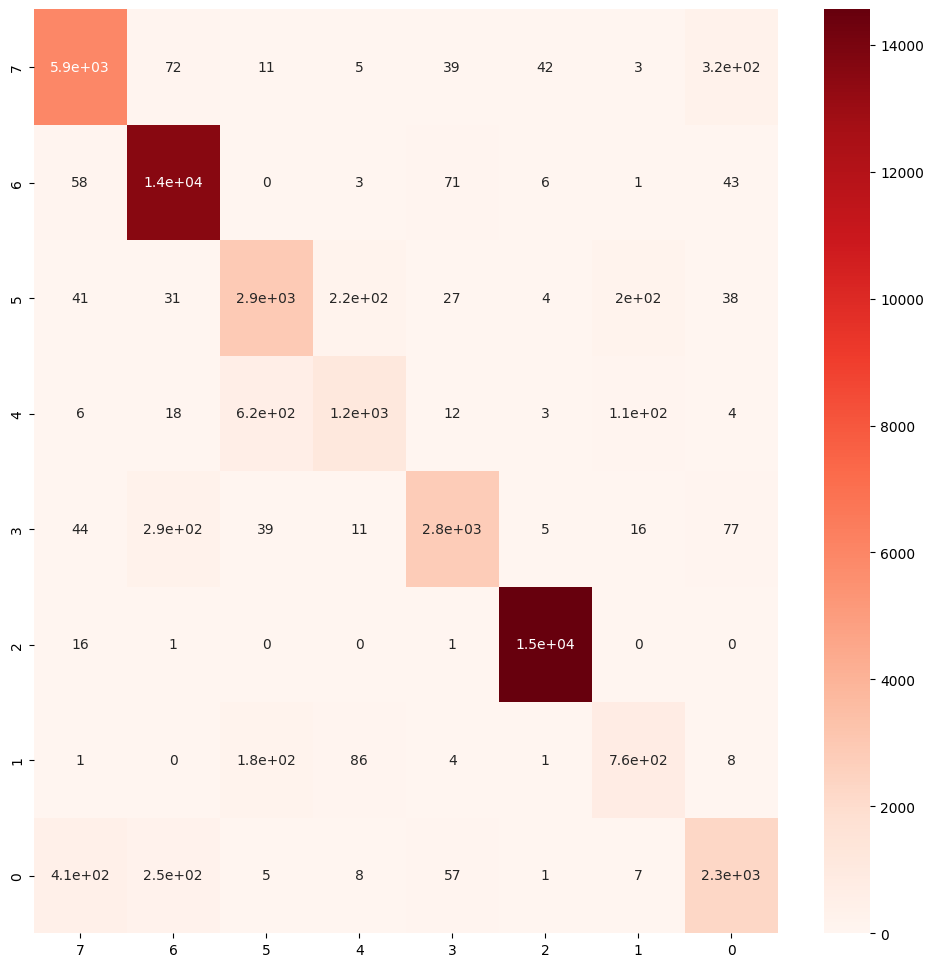

In [70]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(12,12))
seaborn.heatmap(confusion_matrix_xg, annot=True, cmap="Reds", xticklabels=[ '7', '6', '5', '4', '3', '2', '1', '0'], yticklabels=['7', '6', '5', '4', '3', '2', '1', '0'])
plt.show()

In [71]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_xg, output_dict=True)

In [72]:
report

{'0': {'precision': 0.9108103952022144,
  'recall': 0.9235927023234056,
  'f1-score': 0.91715701455559,
  'support': 6413.0},
 '1': {'precision': 0.9533412971681541,
  'recall': 0.9867626736489926,
  'f1-score': 0.9697641172265904,
  'support': 13749.0},
 '2': {'precision': 0.775,
  'recall': 0.8399885909868796,
  'f1-score': 0.8061866958664111,
  'support': 3506.0},
 '3': {'precision': 0.7782258064516129,
  'recall': 0.6,
  'f1-score': 0.6775892334698654,
  'support': 1930.0},
 '4': {'precision': 0.9307288246881156,
  'recall': 0.8536585365853658,
  'f1-score': 0.8905292916601225,
  'support': 3321.0},
 '5': {'precision': 0.9957595239723686,
  'recall': 0.9987651780201687,
  'f1-score': 0.9972600863072814,
  'support': 14577.0},
 '6': {'precision': 0.6923076923076923,
  'recall': 0.731357552581262,
  'f1-score': 0.7112970711297071,
  'support': 1046.0},
 '7': {'precision': 0.8242074927953891,
  'recall': 0.7556142668428005,
  'f1-score': 0.78842177808408,
  'support': 3028.0},
 'accur

## Random Forest

In [73]:
rf = RandomForestClassifier(n_estimators = 100, random_state=42)
s_t = time.time()
rf.fit(X_train, y_train)
e_t = time.time()

total = e_t - s_t

In [74]:
total

50.84155011177063

In [75]:
y_pred = rf.predict(X_test)

In [76]:
accuracy = accuracy_score(y_test, y_pred)

In [77]:
accuracy

0.9184149674164389

In [78]:
mae_error_rf = mean_absolute_error(y_test, y_pred)
mae_error_rf

0.2961950809333614

In [79]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

In [80]:
report

{'0': {'precision': 0.9111389236545682,
  'recall': 0.9081553095275222,
  'f1-score': 0.9096446700507614,
  'support': 6413.0},
 '1': {'precision': 0.9540026849431216,
  'recall': 0.9820350570950614,
  'f1-score': 0.9678159271736793,
  'support': 13749.0},
 '2': {'precision': 0.7823878069432684,
  'recall': 0.7906446092413006,
  'f1-score': 0.7864945382323734,
  'support': 3506.0},
 '3': {'precision': 0.7108977978543196,
  'recall': 0.6523316062176165,
  'f1-score': 0.6803566603620643,
  'support': 1930.0},
 '4': {'precision': 0.8965850515463918,
  'recall': 0.8380006022282445,
  'f1-score': 0.8663035019455253,
  'support': 3321.0},
 '5': {'precision': 0.9945358923570794,
  'recall': 0.9989023804623722,
  'f1-score': 0.9967143541652406,
  'support': 14577.0},
 '6': {'precision': 0.6470588235294118,
  'recall': 0.6625239005736138,
  'f1-score': 0.6547000472366556,
  'support': 1046.0},
 '7': {'precision': 0.7927461139896373,
  'recall': 0.7579260237780714,
  'f1-score': 0.77494512915752

In [81]:
from sklearn.metrics import confusion_matrix
confusion_matrix_rn = confusion_matrix(y_test, y_pred_xg)

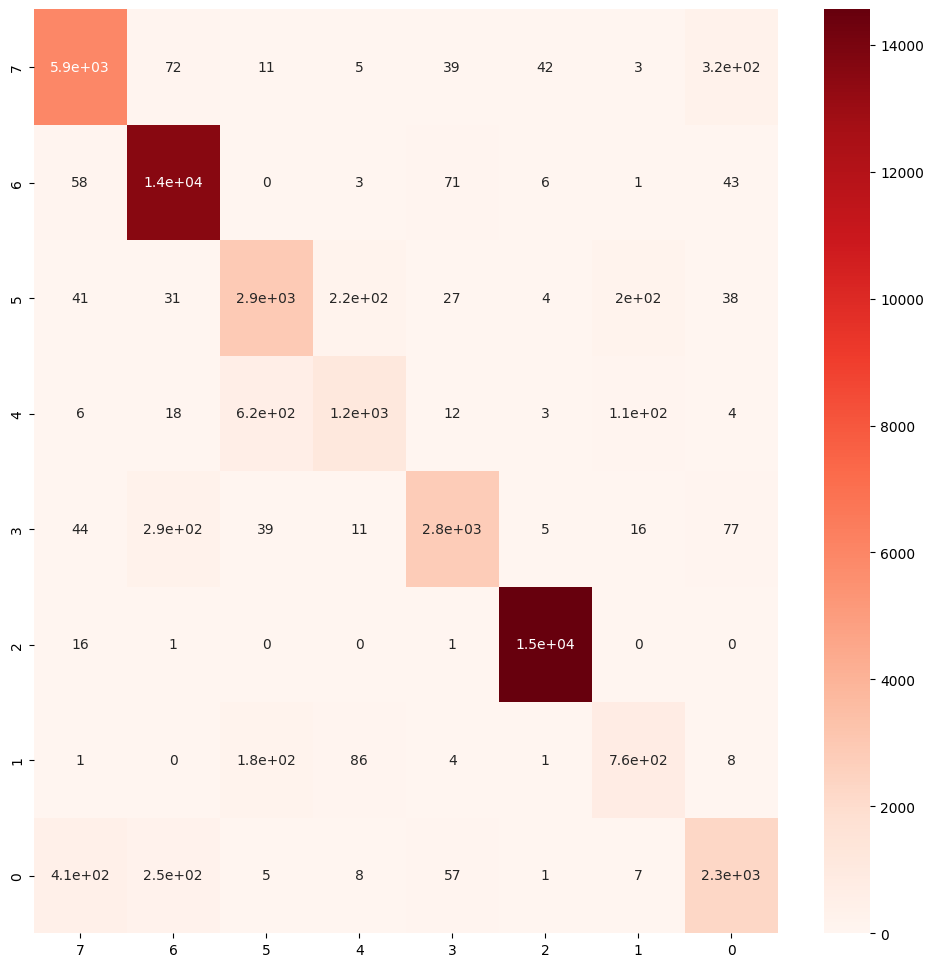

In [82]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(12,12))
seaborn.heatmap(confusion_matrix_rn, annot=True, cmap="Reds", xticklabels=['7', '6', '5', '4', '3', '2', '1', '0'], yticklabels=['7', '6', '5', '4', '3', '2', '1', '0'])
plt.show()

## CatBoost

In [83]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.6 MB/s eta 0:00:00


In [84]:
from catboost import CatBoostClassifier

In [85]:
list(X_train.columns)

['Flow Bytes/s',
 'Total Length of Fwd Packet',
 'Subflow Bwd Packets',
 'Protocol',
 'Bwd Packet Length Max',
 'FWD Init Win Bytes',
 'Label-1',
 'Bwd IAT Total',
 'ACK Flag Count',
 'Flow IAT Mean',
 'PSH Flag Count',
 'CWE Flag Count',
 'Fwd IAT Std',
 'FIN Flag Count',
 'Fwd Bulk Rate Avg',
 'Flow IAT Std',
 'Flow Duration',
 'Bwd IAT Min',
 'Average Packet Size',
 'Dst Port',
 'Bwd Header Length',
 'Idle Std',
 'Total Bwd packets',
 'Bwd Packets/s',
 'Bwd Segment Size Avg',
 'Fwd Packets/s',
 'Fwd Packet Length Max',
 'Packet Length Variance',
 'Bwd Packet Length Mean',
 'Fwd Header Length',
 'Fwd Seg Size Min',
 'SYN Flag Count',
 'Fwd Packet/Bulk Avg',
 'Bwd Bytes/Bulk Avg',
 'Total Fwd Packet',
 'Subflow Bwd Bytes',
 'Bwd Init Win Bytes',
 'Fwd Packet Length Std',
 'Fwd IAT Total',
 'Fwd Segment Size Avg',
 'Bwd IAT Max',
 'Flow IAT Min',
 'Bwd IAT Std',
 'Fwd IAT Min',
 'Bwd Packet/Bulk Avg',
 'Down/Up Ratio',
 'Fwd Act Data Pkts',
 'Total Length of Bwd Packet',
 'Packet Lengt

In [86]:
cat_f = list(X_train.columns)

In [87]:
cb = CatBoostClassifier(iterations=2000, loss_function = 'MultiClass', cat_features = ['Label-1'])

In [88]:
s_t = time.time()
cb.fit(X_train, y_train)
e_t = time.time()
total = e_t - s_t

Learning rate set to 0.05601
0:	learn: 1.8535069	total: 1.67s	remaining: 55m 34s
1:	learn: 1.6990271	total: 3.59s	remaining: 59m 42s
2:	learn: 1.5802120	total: 5.39s	remaining: 59m 51s
3:	learn: 1.4799065	total: 8.56s	remaining: 1h 11m 10s
4:	learn: 1.3979364	total: 11.3s	remaining: 1h 15m 20s
5:	learn: 1.3229113	total: 13.5s	remaining: 1h 14m 39s
6:	learn: 1.2503171	total: 15.4s	remaining: 1h 13m 3s
7:	learn: 1.1861056	total: 17.1s	remaining: 1h 10m 46s
8:	learn: 1.1309958	total: 18.9s	remaining: 1h 9m 37s
9:	learn: 1.0844913	total: 20.8s	remaining: 1h 9m 6s
10:	learn: 1.0400837	total: 23.9s	remaining: 1h 12m 3s
11:	learn: 1.0002644	total: 26.4s	remaining: 1h 12m 57s
12:	learn: 0.9643538	total: 28.1s	remaining: 1h 11m 34s
13:	learn: 0.9326952	total: 29.6s	remaining: 1h 9m 52s
14:	learn: 0.9036999	total: 31.5s	remaining: 1h 9m 28s
15:	learn: 0.8746718	total: 33s	remaining: 1h 8m 13s
16:	learn: 0.8483485	total: 33.9s	remaining: 1h 5m 54s
17:	learn: 0.8254355	total: 34.8s	remaining: 1h 3

In [89]:
print("Time = ", total)

Time =  1909.2215387821198


In [90]:
y_pred_cb = cb.predict(X_test)

In [91]:
accuracy = accuracy_score(y_test, y_pred_cb)

In [92]:
accuracy

0.917910447761194

In [93]:
mae_error_cb = mean_absolute_error(y_test, y_pred_cb)
mae_error_cb

0.2963212108471726

In [94]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_cb, output_dict=True)

In [95]:
report

{'0': {'precision': 0.9038819875776397,
  'recall': 0.9076875097458288,
  'f1-score': 0.9057807515755076,
  'support': 6413.0},
 '1': {'precision': 0.9468085106382979,
  'recall': 0.9839261037166339,
  'f1-score': 0.9650105218104648,
  'support': 13749.0},
 '2': {'precision': 0.758558091286307,
  'recall': 0.8342840844266971,
  'f1-score': 0.7946210268948656,
  'support': 3506.0},
 '3': {'precision': 0.7668500687757909,
  'recall': 0.5777202072538861,
  'f1-score': 0.6589834515366431,
  'support': 1930.0},
 '4': {'precision': 0.9145412388208016,
  'recall': 0.8313760915386932,
  'f1-score': 0.8709779179810726,
  'support': 3321.0},
 '5': {'precision': 0.9912711402073104,
  'recall': 0.9971873499348288,
  'f1-score': 0.9942204438972675,
  'support': 14577.0},
 '6': {'precision': 0.6859504132231405,
  'recall': 0.7141491395793499,
  'f1-score': 0.6997658079625293,
  'support': 1046.0},
 '7': {'precision': 0.808695652173913,
  'recall': 0.7371202113606341,
  'f1-score': 0.7712508638562543

In [96]:
from sklearn.metrics import confusion_matrix
confusion_matrix_cb = confusion_matrix(y_test, y_pred_cb)

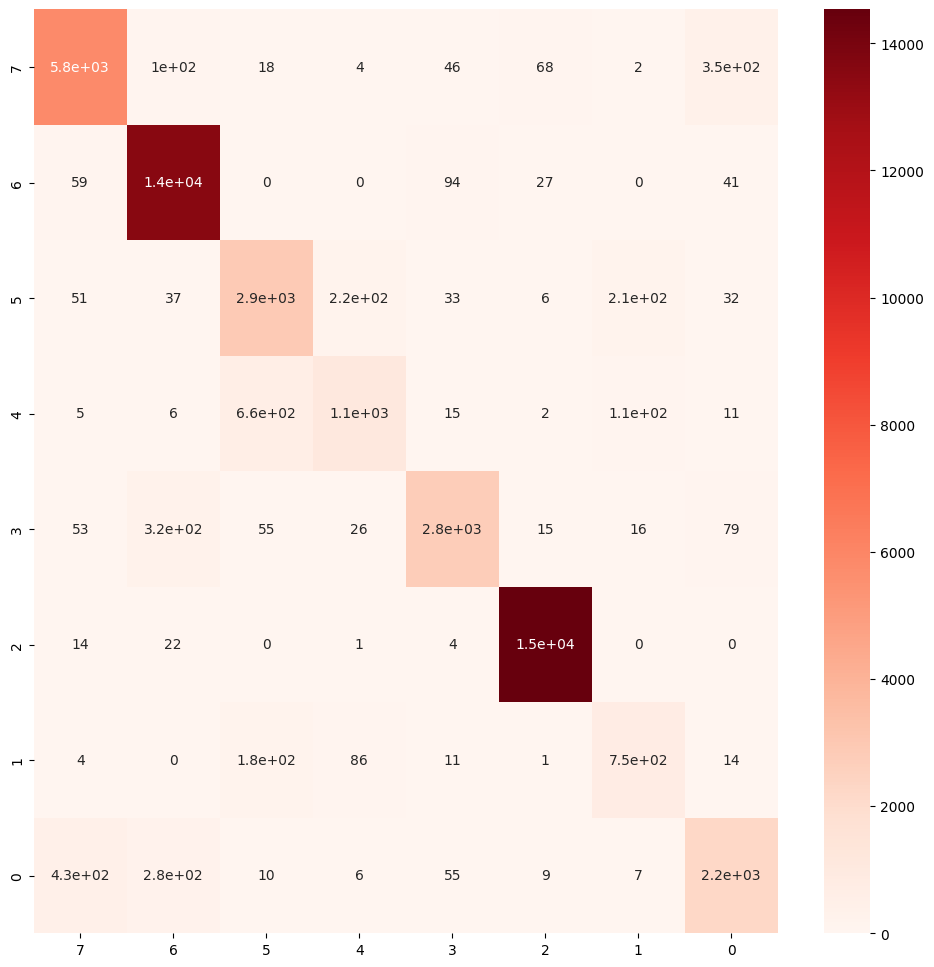

In [97]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(12,12))
seaborn.heatmap(confusion_matrix_cb, annot=True, cmap="Reds", xticklabels=['7', '6', '5', '4', '3', '2', '1', '0'], yticklabels=['7', '6', '5', '4', '3', '2', '1', '0'])
plt.show()

## Logistic Regression

In [98]:
from sklearn.linear_model import LogisticRegression

In [99]:
lr = LogisticRegression()

In [100]:
s_t = time.time()
lr.fit(X_train, y_train)
e_t = time.time()
total = e_t - s_t


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
print("Time = ", total)

Time =  33.16582798957825


In [102]:
y_pred_lr = lr.predict(X_test)

In [103]:
accuracy = accuracy_score(y_test, y_pred_lr)

In [104]:
accuracy

0.3527012823207904

In [105]:
mae_error_lr = mean_absolute_error(y_test, y_pred_lr)
mae_error_lr

2.3146941349590078

In [106]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_lr, output_dict=True)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [107]:
report

{'0': {'precision': 0.2859646194926569,
  'recall': 0.5343832839544674,
  'f1-score': 0.3725607435994999,
  'support': 6413.0},
 '1': {'precision': 0.6544622425629291,
  'recall': 0.22881664121026984,
  'f1-score': 0.3390816986419487,
  'support': 13749.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3506.0},
 '3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1930.0},
 '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3321.0},
 '5': {'precision': 0.33261592643318333,
  'recall': 0.6997324552377032,
  'f1-score': 0.45089848153305484,
  'support': 14577.0},
 '6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1046.0},
 '7': {'precision': 0.04424778761061947,
  'recall': 0.0016512549537648614,
  'f1-score': 0.003183699458771092,
  'support': 3028.0},
 'accuracy': 0.3527012823207904,
 'macro avg': {'precision': 0.16466132201242362,
  'recall': 0.18307295441952565,
  'f1-score': 0.14571557790415934,
  'support': 47570.

In [108]:
from sklearn.metrics import confusion_matrix
confusion_matrix_lr = confusion_matrix(y_test, y_pred_lr)

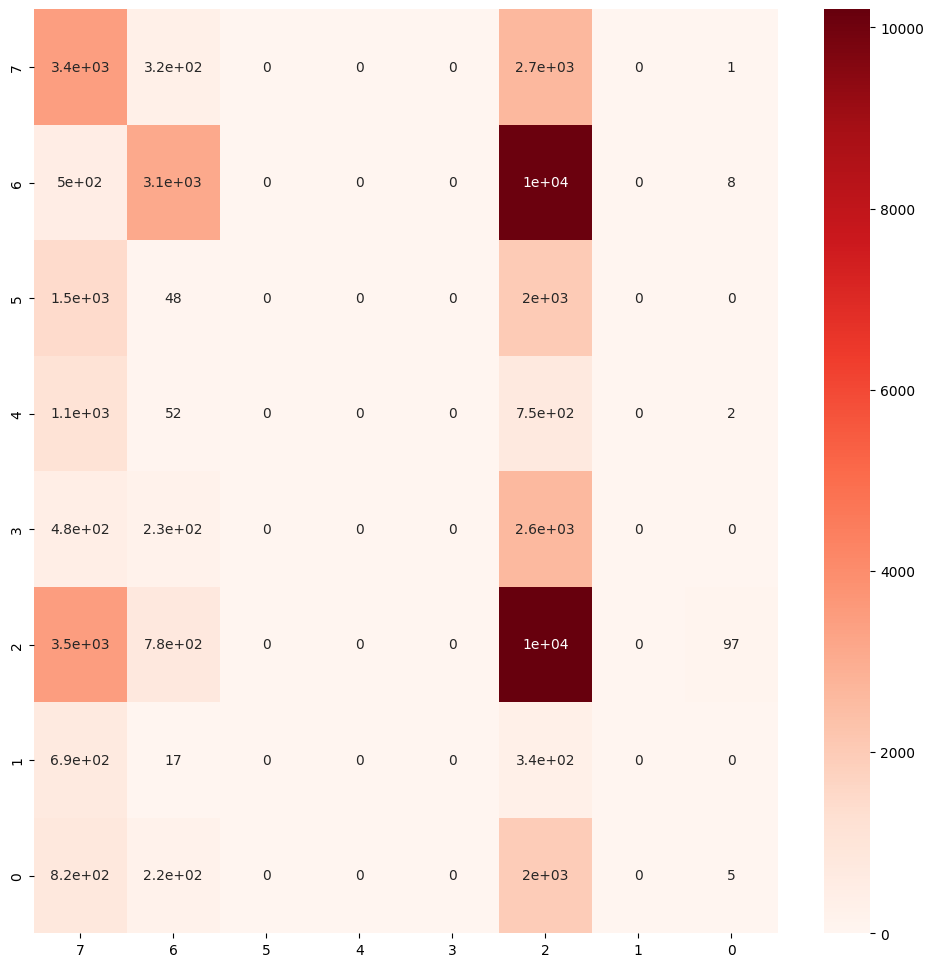

In [109]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(12,12))
seaborn.heatmap(confusion_matrix_lr, annot=True, cmap="Reds", xticklabels=['7', '6', '5', '4', '3', '2', '1', '0'], yticklabels=['7', '6', '5', '4', '3', '2', '1', '0'])
plt.show()